# Analisis Numerik: Regresi dan Pencarian Akar Pada Studi Kasus Sintesis Data Penjualan Donat Harian (5 Gerai)

**Nama:** Nafitry Eka Arya Winanda (Nanda)
**NPM:** 25083010030 — Kelas A083
**Program Studi:** Sains Data

**Deskripsi Tugas:**
1. Membuat plot *Jumlah Penjualan vs Revenue* untuk kelima gerai 
2. Menerapkan regresi untuk melihat bentuk tren revenue terhadap volume penjualan 
3. Mencari volume penjualan yang menghasilkan *Break Even Point* (BEP) untuk masing-masing
   gerai berdasarkan hasil regresi, menggunakan metode pencarian akar 

**Link Repositori (GitHub/GitLab):** https://github.com/nafitryeka/25083010010_Nafitry-Eka-Arya-Winanda_Tugas-1_Analisis-Numerik.git


## 0. Import Library dan Konfigurasi

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

rupiah = mticker.FuncFormatter(lambda x, _: f"Rp{x:,.0f}")


## 1. Memuat dan Mengeksplorasi Data

In [2]:

df = pd.read_csv('sintesis_data_donat_harian.csv')
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
print("Dimensi data:", df.shape)
df.head(10)


Dimensi data: (450, 8)


,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333
5,2026-01-06,Gerai A,25000,90,2250000,765000,1683333,-198333
6,2026-01-07,Gerai A,25000,85,2125000,722500,1683333,-280833
7,2026-01-08,Gerai A,25000,87,2175000,739500,1683333,-247833
8,2026-01-09,Gerai A,25000,84,2100000,714000,1683333,-297333
9,2026-01-10,Gerai A,25000,119,2975000,1011500,1683333,280167


In [3]:

print("Periode data :", df['Tanggal'].min().date(), "s/d", df['Tanggal'].max().date())
print("Daftar gerai :", sorted(df['Gerai'].unique()))
df.groupby('Gerai').size().rename('Jumlah Hari Observasi')


Periode data : 2026-01-01 s/d 2026-03-31
Daftar gerai : ['Gerai A', 'Gerai B', 'Gerai C', 'Gerai D', 'Gerai E']


Gerai
Gerai A    90
Gerai B    90
Gerai C    90
Gerai D    90
Gerai E    90
Name: Jumlah Hari Observasi, dtype: int64

### 1.1 Strategi Marketing Tiap Gerai

Sebagai konteks bisnis, berikut strategi marketing masing-masing gerai (diberikan pada soal):

In [4]:

strategi_marketing = {
    'Gerai A': 'Premium Gourmet — harga tinggi, niche terbatas, kafe specialty',
    'Gerai B': 'Mass Market Volume — harga murah, margin tertekan inflasi bahan',
    'Gerai C': 'Promo Agresif — diskon awal, iklan moderate-high',
    'Gerai D': 'Mall Premium Flagship — sewa lokasi tinggi',
    'Gerai E': 'Cloud Kitchen — fokus app delivery, terkena komisi platform 18%',
}
pd.Series(strategi_marketing, name='Strategi Marketing').to_frame()


,Strategi Marketing
Gerai A,"Premium Gourmet — harga tinggi, niche terbatas..."
Gerai B,"Mass Market Volume — harga murah, margin terte..."
Gerai C,"Promo Agresif — diskon awal, iklan moderate-high"
Gerai D,Mall Premium Flagship — sewa lokasi tinggi
Gerai E,"Cloud Kitchen — fokus app delivery, terkena ko..."


### 1.2 Ringkasan Parameter Bisnis per Gerai

Karena harga jual dan biaya variabel per unit konstan setiap hari untuk satu gerai (hanya
volume penjualan yang berfluktuasi harian), kita bisa merangkum parameter dasar tiap gerai
sebelum masuk ke regresi dan pencarian akar.

In [5]:

ringkasan = df.groupby('Gerai').apply(lambda d: pd.Series({
    'Harga Jual/Unit (Rp)'        : d['Harga Jual (Rp)'].iloc[0],
    'Biaya Variabel/Unit (Rp)'    : (d['Biaya Variabel (Rp)'] / d['Jumlah Terjual (Unit)']).mean(),
    'Fixed Cost Harian (Rp)'      : d['Fixed Cost Harian (Rp)'].iloc[0],
    'Rata-rata Volume/Hari (unit)': d['Jumlah Terjual (Unit)'].mean(),
    'Rata-rata Balance/Hari (Rp)' : d['Balance (Rp)'].mean(),
}), include_groups=False)
ringkasan


,Harga Jual/Unit (Rp),Biaya Variabel/Unit (Rp),Fixed Cost Harian (Rp),Rata-rata Volume/Hari (unit),Rata-rata Balance/Hari (Rp)
Gerai,,,,,
Gerai A,"25,000.00","8,500.00","1,683,333.00",99.10,"-48,183.00"
Gerai B,"8,000.00","4,160.00","733,333.00",527.50,"1,292,267.00"
Gerai C,"11,000.00","4,840.00","1,733,333.00",328.93,"292,896.33"
Gerai D,"20,000.00","7,200.00","2,666,666.00",149.83,"-748,799.33"
Gerai E,"15,000.00","6,300.00","800,000.00",226.64,"1,171,806.67"


## 2. Bagian A — Visualisasi Jumlah Penjualan vs Revenue 

Revenue di sini menggunakan kolom **Pendapatan Kotor (Rp)** (harga jual × jumlah unit terjual).

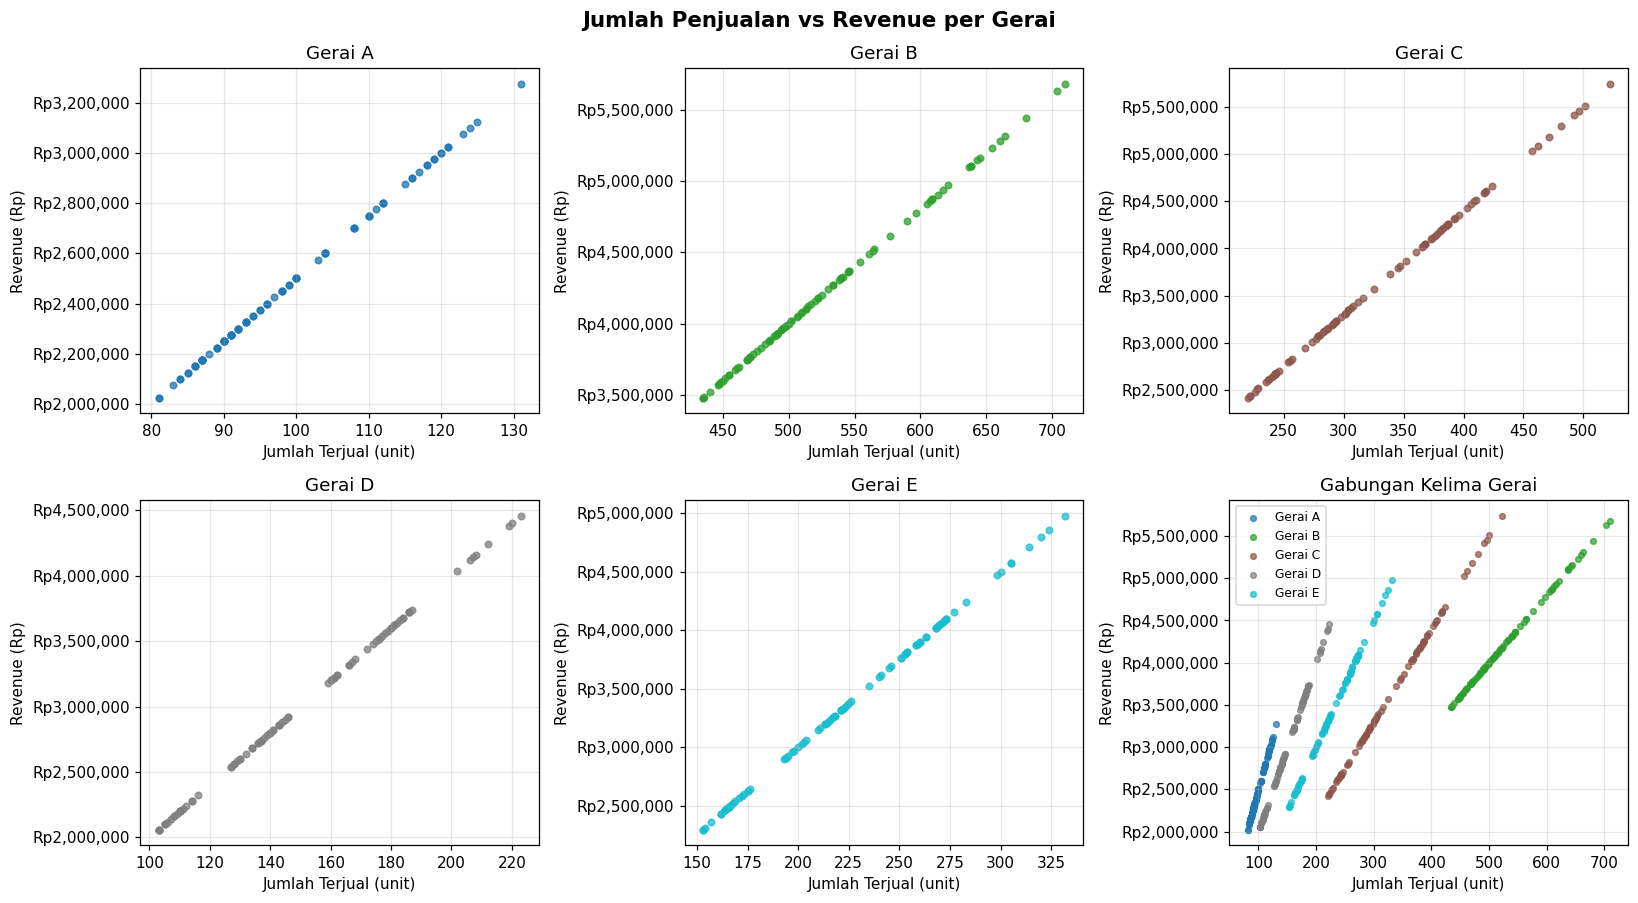

In [6]:

gerai_list = sorted(df['Gerai'].unique())
warna = plt.cm.tab10(np.linspace(0, 1, len(gerai_list)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, g in enumerate(gerai_list):
    d = df[df['Gerai'] == g].sort_values('Jumlah Terjual (Unit)')
    axes[i].scatter(d['Jumlah Terjual (Unit)'], d['Pendapatan Kotor (Rp)'],
                     s=18, color=warna[i], alpha=0.75)
    axes[i].set_title(g)
    axes[i].set_xlabel('Jumlah Terjual (unit)')
    axes[i].set_ylabel('Revenue (Rp)')
    axes[i].yaxis.set_major_formatter(rupiah)

# panel gabungan pada slot terakhir (index 5)
ax = axes[5]
for i, g in enumerate(gerai_list):
    d = df[df['Gerai'] == g].sort_values('Jumlah Terjual (Unit)')
    ax.scatter(d['Jumlah Terjual (Unit)'], d['Pendapatan Kotor (Rp)'],
               s=14, color=warna[i], alpha=0.7, label=g)
ax.set_title('Gabungan Kelima Gerai')
ax.set_xlabel('Jumlah Terjual (unit)')
ax.set_ylabel('Revenue (Rp)')
ax.yaxis.set_major_formatter(rupiah)
ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Jumlah Penjualan vs Revenue per Gerai', y=1.02, fontsize=14, fontweight='bold')
plt.show()


**Pengamatan awal:** Untuk setiap gerai, titik-titik data tersebar mengikuti pola garis
lurus yang melewati titik asal (0,0) — masuk akal karena Revenue = Harga Jual × Volume, dan
harga jual per gerai konstan sepanjang periode observasi. Kemiringan (slope) garis berbeda
antar gerai, sesuai perbedaan harga jual pada masing-masing strategi marketing.

## 3. Bagian B — Regresi: Bentuk Tren Revenue terhadap Volume 

### 3.1 Implementasi Regresi dari Nol

Digunakan metode **Ordinary Least Squares (OLS)** dengan persamaan normal:

> **β̂ = (XᵀX)⁻¹ Xᵀy**

Tiga bentuk model dicoba dan dibandingkan lewat koefisien determinasi **R²**:
- **Linear**: y = β0 + β1·x
- **Polinomial derajat 2**: y = β0 + β1·x + β2·x²
- **Eksponensial**: y = a·e^(b·x) (dilinearkan menjadi ln y = ln a + b·x)

In [7]:

def matriks_desain(x, derajat):
    # Bangun matriks desain Vandermonde [1, x, x^2, ..., x^derajat].
    x = np.asarray(x, dtype=float)
    return np.vstack([x**p for p in range(derajat + 1)]).T

def fit_least_squares(x, y, derajat=1):
    # Estimasi koefisien OLS lewat persamaan normal (X^T X) beta = X^T y.
    X = matriks_desain(x, derajat)
    y = np.asarray(y, dtype=float)
    XtX = X.T @ X
    Xty = X.T @ y
    beta = np.linalg.solve(XtX, Xty)
    return beta

def prediksi_poly(beta, x):
    derajat = len(beta) - 1
    X = matriks_desain(x, derajat)
    return X @ beta

def r_squared(y_aktual, y_prediksi):
    y_aktual = np.asarray(y_aktual, dtype=float)
    ss_res = np.sum((y_aktual - y_prediksi) ** 2)
    ss_tot = np.sum((y_aktual - np.mean(y_aktual)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 1.0

def fit_eksponensial(x, y):
    # y = a * exp(b*x)  ->  ln(y) = ln(a) + b*x, lalu fit linear pada ln(y).
    ln_y = np.log(np.asarray(y, dtype=float))
    beta = fit_least_squares(x, ln_y, derajat=1)
    ln_a, b = beta
    return np.exp(ln_a), b

def prediksi_eksponensial(a, b, x):
    return a * np.exp(b * np.asarray(x, dtype=float))


### 3.2 Membandingkan Model Revenue = f(Volume) untuk Tiap Gerai

In [8]:

hasil_regresi = {}

for g in gerai_list:
    d = df[df['Gerai'] == g].sort_values('Jumlah Terjual (Unit)')
    v = d['Jumlah Terjual (Unit)'].values.astype(float)
    rev = d['Pendapatan Kotor (Rp)'].values.astype(float)

    beta_lin = fit_least_squares(v, rev, derajat=1)
    r2_lin = r_squared(rev, prediksi_poly(beta_lin, v))

    beta_poly = fit_least_squares(v, rev, derajat=2)
    r2_poly = r_squared(rev, prediksi_poly(beta_poly, v))

    a_exp, b_exp = fit_eksponensial(v, rev)
    r2_exp = r_squared(rev, prediksi_eksponensial(a_exp, b_exp, v))

    hasil_regresi[g] = {
        'beta_linear': beta_lin, 'r2_linear': r2_lin,
        'beta_poly2': beta_poly, 'r2_poly2': r2_poly,
        'exp_a': a_exp, 'exp_b': b_exp, 'r2_exp': r2_exp,
    }

tabel_r2 = pd.DataFrame({
    g: {'R2 Linear': h['r2_linear'], 'R2 Polinomial-2': h['r2_poly2'], 'R2 Eksponensial': h['r2_exp']}
    for g, h in hasil_regresi.items()
}).T
tabel_r2


,R2 Linear,R2 Polinomial-2,R2 Eksponensial
Gerai A,1.00,1.00,1.00
Gerai B,1.00,1.00,1.00
Gerai C,1.00,1.00,0.98
Gerai D,1.00,1.00,0.99
Gerai E,1.00,1.00,0.99


Ketiga model dicoba secara adil, dan hasilnya menunjukkan **model linear memberikan
R² ≈ 1** untuk kelima gerai — konsisten dengan sifat data (Revenue = Harga × Volume,
harga konstan per gerai). Model polinomial derajat-2 tidak memberikan perbaikan berarti
(koefisien kuadratiknya mendekati nol), dan model eksponensial jelas kurang sesuai karena
data pada dasarnya proporsional, bukan tumbuh eksponensial. Oleh karena itu **model linear
dipilih sebagai model tren revenue** untuk seluruh gerai.

In [9]:

print("Model linear terpilih: Revenue(v) = beta0 + beta1 * v\n")
for g in gerai_list:
    b0, b1 = hasil_regresi[g]['beta_linear']
    print(f"{g:10s}: Revenue(v) = {b0:>10,.2f} + {b1:>10,.2f} * v   (R^2 = {hasil_regresi[g]['r2_linear']:.6f})")


Model linear terpilih: Revenue(v) = beta0 + beta1 * v

Gerai A   : Revenue(v) =      -0.00 +  25,000.00 * v   (R^2 = 1.000000)
Gerai B   : Revenue(v) =      -0.00 +   8,000.00 * v   (R^2 = 1.000000)
Gerai C   : Revenue(v) =      -0.00 +  11,000.00 * v   (R^2 = 1.000000)
Gerai D   : Revenue(v) =       0.00 +  20,000.00 * v   (R^2 = 1.000000)
Gerai E   : Revenue(v) =      -0.00 +  15,000.00 * v   (R^2 = 1.000000)


**Interpretasi:** Untuk kelima gerai, intersep (beta0) model revenue mendekati nol dan
koefisien kemiringan (beta1) sama persis dengan harga jual per unit masing-masing gerai
(Rp25.000 untuk A, Rp8.000 untuk B, Rp11.000 untuk C, Rp20.000 untuk D, Rp15.000 untuk E).
Ini menegaskan bahwa **setiap tambahan satu unit donat terjual menambah revenue sebesar
harga jual per unit gerai tersebut** — tidak ada efek skala (diskon kuantitas atau kenaikan
harga bertahap) yang tertangkap dalam data historis ini, sehingga hubungan revenue–volume
murni proporsional (linear melalui titik asal).

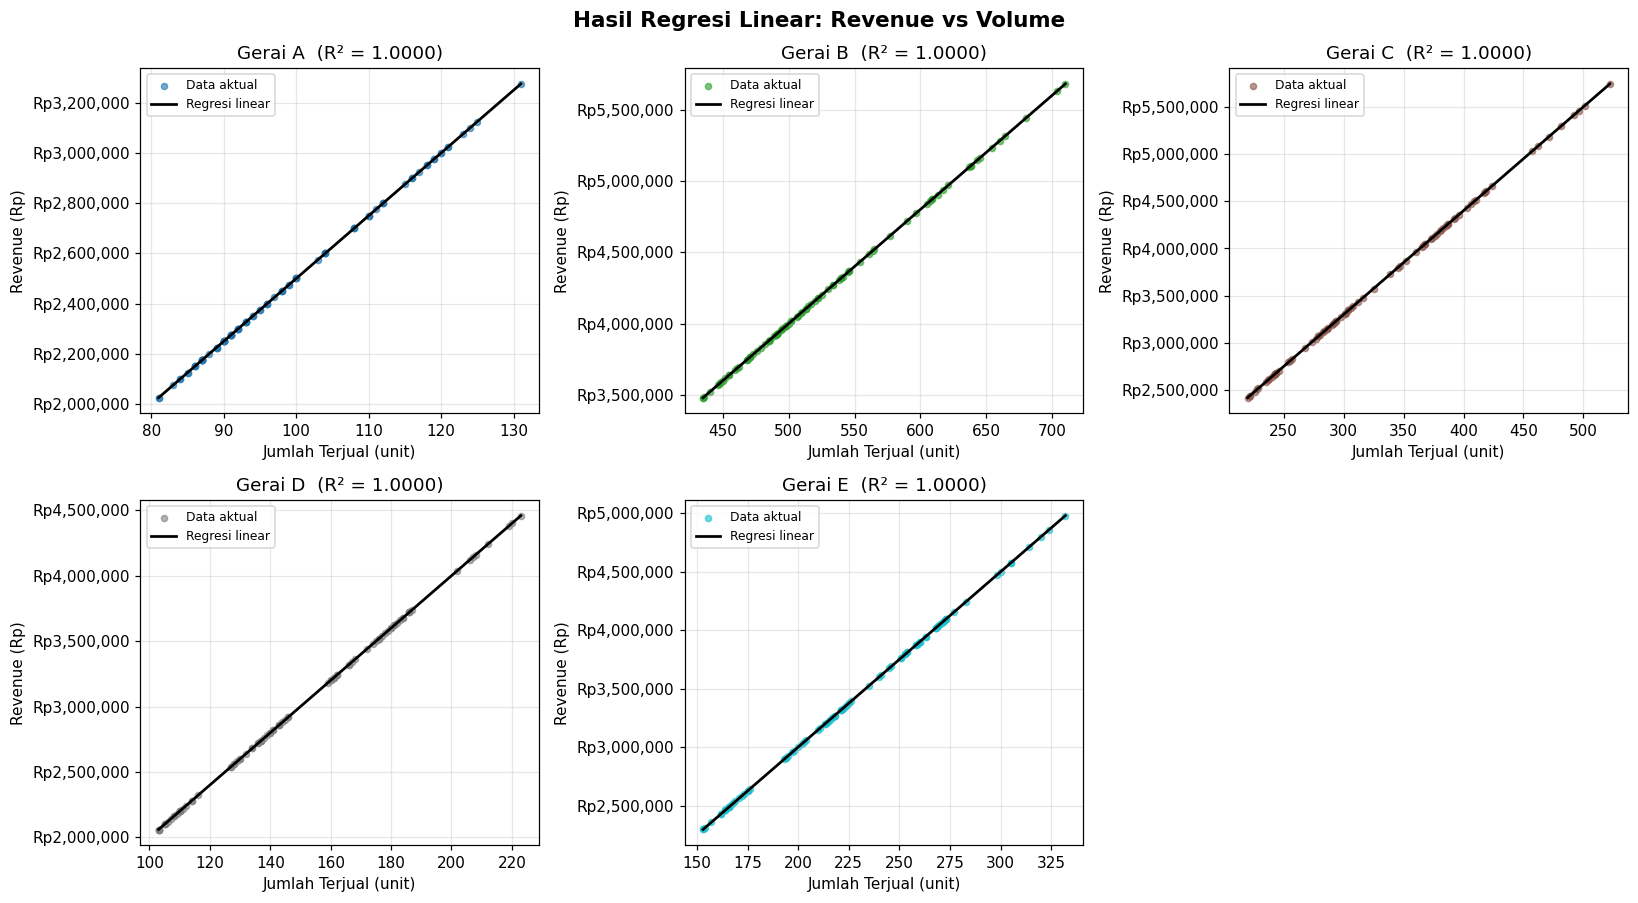

In [10]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, g in enumerate(gerai_list):
    d = df[df['Gerai'] == g].sort_values('Jumlah Terjual (Unit)')
    v = d['Jumlah Terjual (Unit)'].values.astype(float)
    rev = d['Pendapatan Kotor (Rp)'].values.astype(float)
    v_line = np.linspace(v.min(), v.max(), 100)
    rev_line = prediksi_poly(hasil_regresi[g]['beta_linear'], v_line)

    axes[i].scatter(v, rev, s=16, color=warna[i], alpha=0.6, label='Data aktual')
    axes[i].plot(v_line, rev_line, color='black', lw=1.8, label='Regresi linear')
    axes[i].set_title(f"{g}  (R² = {hasil_regresi[g]['r2_linear']:.4f})")
    axes[i].set_xlabel('Jumlah Terjual (unit)')
    axes[i].set_ylabel('Revenue (Rp)')
    axes[i].yaxis.set_major_formatter(rupiah)
    axes[i].legend(fontsize=8)
axes[5].axis('off')
plt.tight_layout()
plt.suptitle('Hasil Regresi Linear: Revenue vs Volume', y=1.02, fontsize=14, fontweight='bold')
plt.show()


**Interpretasi grafik:** Garis regresi linear (hitam) berimpit hampir sempurna dengan
seluruh titik data aktual pada kelima gerai (R² = 1,0000), sehingga tidak diperlukan bentuk
model lain (polinomial/eksponensial) yang lebih kompleks — model linear sudah cukup dan
paling mudah diinterpretasikan untuk merepresentasikan hubungan Revenue terhadap Volume.

### 3.3 Model Biaya Total terhadap Volume

Untuk menentukan *breakeven point* pada Bagian C, kita juga memerlukan model **Biaya
Total = f(Volume)**. Biaya Total harian = Biaya Variabel + Fixed Cost Harian. Karena biaya
variabel per unit dan fixed cost konstan per gerai, model ini secara alami juga linear:
Cost(v) = FC + VC·v. Kita tetap mengestimasinya lewat regresi OLS (bukan membaca
langsung dari kolom) agar konsisten dengan pendekatan Bagian B.

In [11]:

for g in gerai_list:
    d = df[df['Gerai'] == g].sort_values('Jumlah Terjual (Unit)')
    v = d['Jumlah Terjual (Unit)'].values.astype(float)
    biaya_total = (d['Biaya Variabel (Rp)'] + d['Fixed Cost Harian (Rp)']).values.astype(float)

    beta_cost = fit_least_squares(v, biaya_total, derajat=1)
    r2_cost = r_squared(biaya_total, prediksi_poly(beta_cost, v))

    hasil_regresi[g]['beta_cost'] = beta_cost
    hasil_regresi[g]['r2_cost'] = r2_cost

print("Model linear biaya total: Cost(v) = beta0 + beta1 * v\n")
for g in gerai_list:
    b0, b1 = hasil_regresi[g]['beta_cost']
    print(f"{g:10s}: Cost(v) = {b0:>10,.2f} + {b1:>10,.2f} * v   (R^2 = {hasil_regresi[g]['r2_cost']:.6f})")


Model linear biaya total: Cost(v) = beta0 + beta1 * v

Gerai A   : Cost(v) = 1,683,333.00 +   8,500.00 * v   (R^2 = 1.000000)
Gerai B   : Cost(v) = 733,333.00 +   4,160.00 * v   (R^2 = 1.000000)
Gerai C   : Cost(v) = 1,733,333.00 +   4,840.00 * v   (R^2 = 1.000000)
Gerai D   : Cost(v) = 2,666,666.00 +   7,200.00 * v   (R^2 = 1.000000)
Gerai E   : Cost(v) = 800,000.00 +   6,300.00 * v   (R^2 = 1.000000)


**Interpretasi:** Intersep model biaya (beta0) sama dengan Fixed Cost Harian tiap gerai
(mis. Rp1.683.333/hari untuk Gerai A yang menyewa kafe specialty, hingga Rp2.666.666/hari
untuk Gerai D yang menyewa lokasi mall — fixed cost tertinggi di antara kelima gerai).
Koefisien kemiringan (beta1) sama dengan biaya variabel per unit (bahan baku, kemasan, dan
—khusus Gerai E— komisi platform delivery 18%). Model ini menunjukkan bahwa **biaya naik
secara linear terhadap volume dengan titik awal (saat volume = 0) sebesar fixed cost harian**
— itulah sebabnya semakin sedikit unit terjual, gerai dengan fixed cost tinggi (D dan C)
akan lebih cepat merugi dibanding gerai dengan fixed cost rendah (E).

## 4. Bagian C — Pencarian Akar: Breakeven Point 

Titik balik modal (BEP) adalah volume v* di mana **Revenue(v) = Cost(v)**, atau
ekuivalen mencari akar dari:

> **f(v) = Revenue(v) − Cost(v) = 0**

dengan Revenue(v) dan Cost(v) diambil dari model regresi linear pada Bagian B. Dua
metode pencarian akar diimplementasikan dari nol: **metode Bisection** dan **metode
Newton-Raphson**, lalu hasil keduanya divalidasi silang dengan solusi aljabar langsung.

In [12]:

def bisection(f, a, b, toleransi=1e-6, maks_iterasi=200):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("f(a) dan f(b) harus berlawanan tanda agar akar terjamin ada di [a,b]")
    riwayat = []
    for i in range(1, maks_iterasi + 1):
        c = (a + b) / 2
        fc = f(c)
        riwayat.append({'iterasi': i, 'a': a, 'b': b, 'c': c, 'f(c)': fc})
        if abs(fc) < toleransi or (b - a) / 2 < toleransi:
            return c, pd.DataFrame(riwayat)
        if fa * fc < 0:
            b = c
        else:
            a, fa = c, fc
    return c, pd.DataFrame(riwayat)

def turunan_numerik(f, x, h=1e-4):
    return (f(x + h) - f(x - h)) / (2 * h)

def newton_raphson(f, x0, toleransi=1e-6, maks_iterasi=100, fprime=None):
    x = x0
    riwayat = []
    for i in range(1, maks_iterasi + 1):
        fx = f(x)
        dfx = fprime(x) if fprime is not None else turunan_numerik(f, x)
        if dfx == 0:
            raise ZeroDivisionError("Turunan nol, Newton-Raphson gagal konvergen")
        x_baru = x - fx / dfx
        riwayat.append({'iterasi': i, 'x': x, 'f(x)': fx, "f'(x)": dfx, 'x_baru': x_baru})
        if abs(x_baru - x) < toleransi:
            return x_baru, pd.DataFrame(riwayat)
        x = x_baru
    return x, pd.DataFrame(riwayat)


In [13]:

bep_hasil = {}

for g in gerai_list:
    beta_rev = hasil_regresi[g]['beta_linear']
    beta_cost = hasil_regresi[g]['beta_cost']

    revenue_model = lambda v, b=beta_rev: prediksi_poly(b, np.array([v]))[0]
    cost_model    = lambda v, b=beta_cost: prediksi_poly(b, np.array([v]))[0]
    f = lambda v: revenue_model(v) - cost_model(v)

    # cari interval bracket [a0, b0] dengan f(a0) dan f(b0) berlawanan tanda
    a0, b0 = 0.0, 50.0
    while f(a0) * f(b0) > 0:
        b0 *= 2
        if b0 > 1e7:
            raise RuntimeError(f"Gagal menemukan interval bracket untuk {g}")

    root_bis, riwayat_bis = bisection(f, a0, b0, toleransi=1e-6)
    root_newton, riwayat_newton = newton_raphson(f, x0=(a0 + b0) / 2, toleransi=1e-6)

    # solusi aljabar langsung sebagai pembanding (karena kedua model linear)
    root_aljabar = (beta_cost[0] - beta_rev[0]) / (beta_rev[1] - beta_cost[1])

    bep_hasil[g] = {
        'BEP (Bisection)': root_bis,
        'BEP (Newton-Raphson)': root_newton,
        'BEP (Aljabar langsung)': root_aljabar,
        'Iterasi Bisection': len(riwayat_bis),
        'Iterasi Newton-Raphson': len(riwayat_newton),
        'riwayat_bisection': riwayat_bis,
        'riwayat_newton': riwayat_newton,
    }

tabel_bep = pd.DataFrame({g: {k: v for k, v in h.items() if not k.startswith('riwayat')}
                           for g, h in bep_hasil.items()}).T
tabel_bep


,BEP (Bisection),BEP (Newton-Raphson),BEP (Aljabar langsung),Iterasi Bisection,Iterasi Newton-Raphson
Gerai A,102.02,102.02,102.02,28.00,2.00
Gerai B,190.97,190.97,190.97,28.00,2.00
Gerai C,281.39,281.39,281.39,29.00,2.00
Gerai D,208.33,208.33,208.33,29.00,2.00
Gerai E,91.95,91.95,91.95,27.00,2.00


**Interpretasi:** Ketiga pendekatan (Bisection, Newton-Raphson, dan solusi aljabar
langsung) menghasilkan volume BEP yang identik untuk setiap gerai, yang membuktikan bahwa
implementasi pencarian akar sudah benar. Bisection membutuhkan sekitar 27–29 iterasi untuk
mencapai toleransi 1e-6 karena setiap langkah hanya memangkas separuh interval, sedangkan
Newton-Raphson langsung konvergen dalam 2 iterasi karena fungsi f(v) berbentuk linear
(turunannya konstan, sehingga sekali langkah sudah menemukan akar eksaknya). Ini menunjukkan
Newton-Raphson jauh lebih efisien di kasus fungsi mulus dan linear seperti ini, sementara
Bisection tetap lebih *robust* untuk fungsi yang tidak diketahui bentuk turunannya.

Contoh rincian iterasi metode Bisection dan Newton-Raphson untuk salah satu gerai (Gerai A):

In [14]:

print("--- Riwayat Bisection: Gerai A (5 iterasi pertama) ---")
display(bep_hasil['Gerai A']['riwayat_bisection'].head())
print("\n--- Riwayat Newton-Raphson: Gerai A ---")
display(bep_hasil['Gerai A']['riwayat_newton'])


--- Riwayat Bisection: Gerai A (5 iterasi pertama) ---


,iterasi,a,b,c,f(c)
0,1,0.00,200.00,100.00,"-33,333.00"
1,2,100.00,200.00,150.00,"791,667.00"
2,3,100.00,150.00,125.00,"379,167.00"
3,4,100.00,125.00,112.50,"172,917.00"
4,5,100.00,112.50,106.25,"69,792.00"



--- Riwayat Newton-Raphson: Gerai A ---


,iterasi,x,f(x),f'(x),x_baru
0,1,100.00,"-33,333.00","16,500.00",102.02
1,2,102.02,0.00,"16,500.00",102.02


**Catatan:** Karena Revenue(v) dan Cost(v) sama-sama fungsi linear terhadap v,
f(v) juga linear sehingga Newton-Raphson konvergen hanya dalam satu iterasi (turunannya
konstan). Metode Bisection memerlukan lebih banyak iterasi karena hanya membagi dua interval
secara bertahap, namun tetap konvergen ke akar yang sama. Kesesuaian ketiga hasil (Bisection,
Newton-Raphson, dan solusi aljabar langsung) mengonfirmasi validitas implementasi.

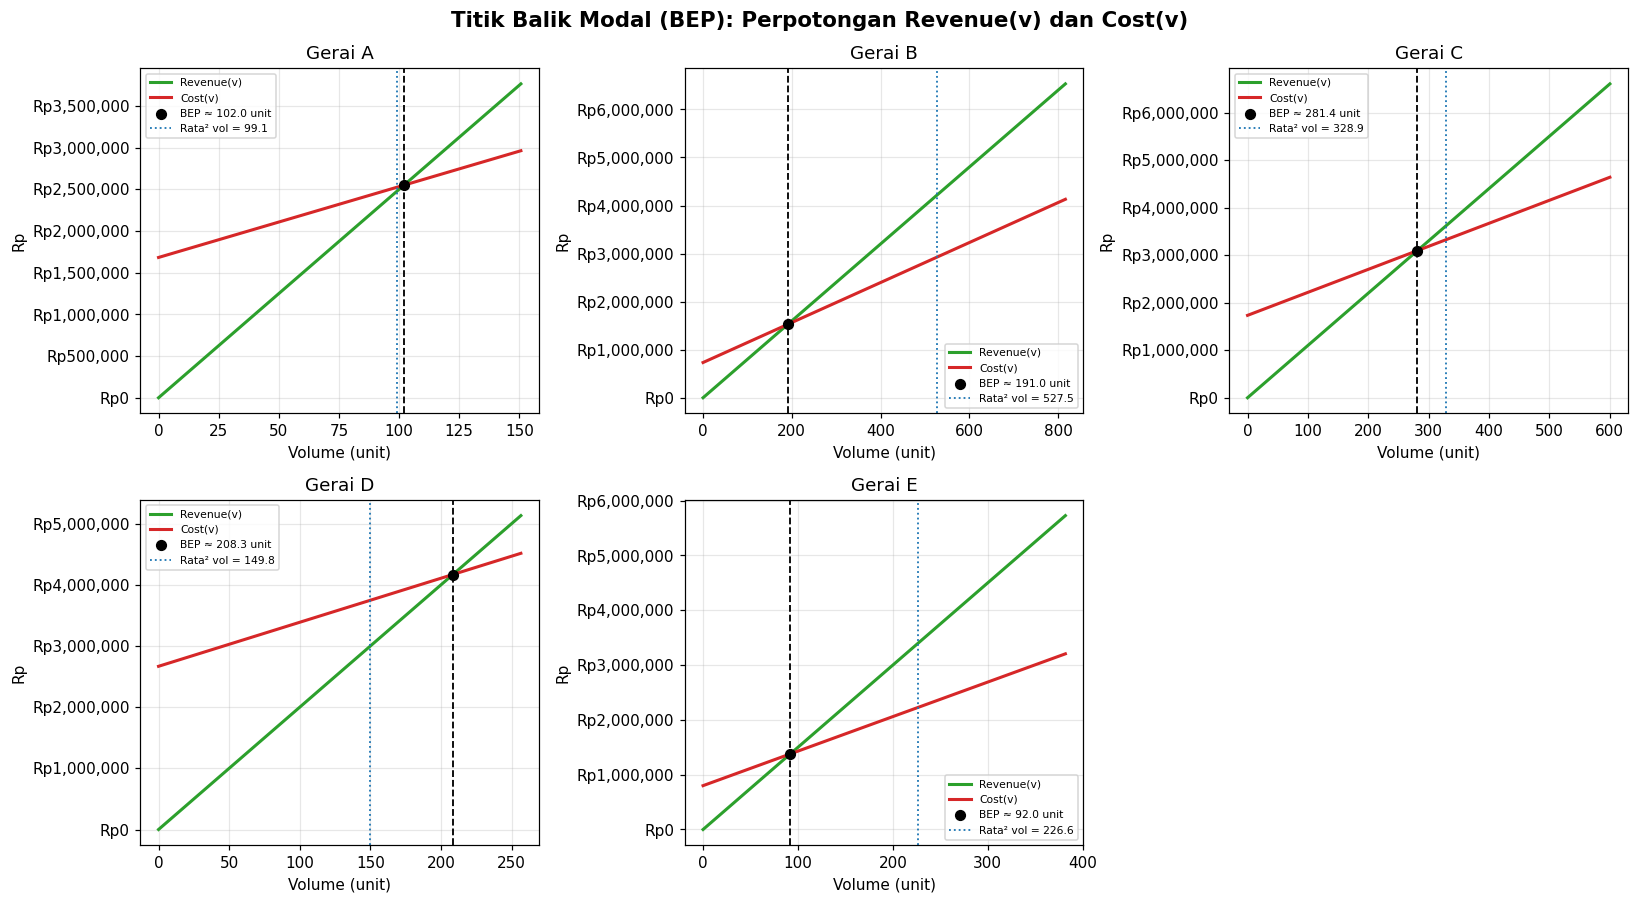

In [15]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, g in enumerate(gerai_list):
    d = df[df['Gerai'] == g].sort_values('Jumlah Terjual (Unit)')
    v_data = d['Jumlah Terjual (Unit)'].values.astype(float)
    bep_v = bep_hasil[g]['BEP (Bisection)']
    v_max = max(v_data.max(), bep_v) * 1.15
    v_line = np.linspace(0, v_max, 100)

    rev_line = prediksi_poly(hasil_regresi[g]['beta_linear'], v_line)
    cost_line = prediksi_poly(hasil_regresi[g]['beta_cost'], v_line)

    axes[i].plot(v_line, rev_line, color='tab:green', lw=2, label='Revenue(v)')
    axes[i].plot(v_line, cost_line, color='tab:red', lw=2, label='Cost(v)')
    axes[i].axvline(bep_v, color='black', ls='--', lw=1.2)
    axes[i].scatter([bep_v], [prediksi_poly(hasil_regresi[g]['beta_linear'], np.array([bep_v]))[0]],
                     color='black', zorder=5, s=40, label=f'BEP ≈ {bep_v:.1f} unit')
    axes[i].axvline(v_data.mean(), color='tab:blue', ls=':', lw=1.2, label=f'Rata² vol = {v_data.mean():.1f}')
    axes[i].set_title(g)
    axes[i].set_xlabel('Volume (unit)')
    axes[i].set_ylabel('Rp')
    axes[i].yaxis.set_major_formatter(rupiah)
    axes[i].legend(fontsize=7)
axes[5].axis('off')
plt.tight_layout()
plt.suptitle('Titik Balik Modal (BEP): Perpotongan Revenue(v) dan Cost(v)', y=1.02, fontsize=14, fontweight='bold')
plt.show()


**Interpretasi grafik:** Titik hitam menandai volume BEP (perpotongan garis hijau
Revenue(v) dan garis merah Cost(v)); garis biru putus-putus menandai rata-rata volume
penjualan aktual harian. Bila garis biru berada **di sebelah kanan** titik BEP (seperti pada
Gerai B, C, dan E), gerai tersebut secara rata-rata beroperasi di zona untung. Sebaliknya,
bila garis biru berada **di sebelah kiri** titik BEP (Gerai A dan D), gerai tersebut secara
rata-rata masih beroperasi di zona rugi — untuk Gerai A jaraknya sangat tipis (hampir pas di
BEP), sedangkan Gerai D tertinggal cukup jauh akibat fixed cost sewa mall yang tinggi.

## 5. Ringkasan Akhir dan Analisis Strategi Marketing

In [16]:

ringkasan_akhir = pd.DataFrame({
    g: {
        'Strategi Marketing': strategi_marketing[g],
        'BEP Volume (unit/hari)': np.ceil(bep_hasil[g]['BEP (Bisection)']),
        'Rata² Volume Aktual (unit/hari)': df[df['Gerai'] == g]['Jumlah Terjual (Unit)'].mean(),
        'Selisih (Aktual - BEP)': df[df['Gerai'] == g]['Jumlah Terjual (Unit)'].mean() - bep_hasil[g]['BEP (Bisection)'],
        'Rata² Balance/Hari (Rp)': df[df['Gerai'] == g]['Balance (Rp)'].mean(),
        'Status Rata-rata': 'Untung' if df[df['Gerai'] == g]['Balance (Rp)'].mean() > 0 else 'Rugi',
    } for g in gerai_list
}).T
ringkasan_akhir


,Strategi Marketing,BEP Volume (unit/hari),Rata² Volume Aktual (unit/hari),Selisih (Aktual - BEP),Rata² Balance/Hari (Rp),Status Rata-rata
Gerai A,"Premium Gourmet — harga tinggi, niche terbatas...",103.00,99.10,-2.92,"-48,183.00",Rugi
Gerai B,"Mass Market Volume — harga murah, margin terte...",191.00,527.50,336.53,"1,292,267.00",Untung
Gerai C,"Promo Agresif — diskon awal, iklan moderate-high",282.00,328.93,47.55,"292,896.33",Untung
Gerai D,Mall Premium Flagship — sewa lokasi tinggi,209.00,149.83,-58.50,"-748,799.33",Rugi
Gerai E,"Cloud Kitchen — fokus app delivery, terkena ko...",92.00,226.64,134.69,"1,171,806.67",Untung


## 6. Kesimpulan

1. **Hubungan jumlah penjualan dan revenue**

   Hasil visualisasi menunjukkan bahwa jumlah penjualan dan revenue pada kelima gerai memiliki hubungan yang linear. Hasil regresi menggunakan metode Ordinary Least Squares (OLS) yang diimplementasikan dari scratch dengan aljabar matriks menghasilkan nilai R² = 1,000000 untuk seluruh gerai. Model yang diperoleh adalah:
   
   - Gerai A: Revenue(v) = 25.000 × v
   - Gerai B: Revenue(v) = 8.000 × v
   - Gerai C: Revenue(v) = 11.000 × v
   - Gerai D: Revenue(v) = 20.000 × v
   - Gerai E: Revenue(v) = 15.000 × v
   
   Hal tersebut menunjukkan bahwa setiap tambahan satu unit donat yang terjual akan meningkatkan revenue sebesar harga jual per unit pada masing-masing gerai. Model polinomial derajat 2 tidak memberikan peningkatan berarti, sedangkan model eksponensial memiliki kecocokan yang lebih rendah pada beberapa gerai. Oleh karena itu, model linear dipilih sebagai model yang paling sesuai untuk menggambarkan hubungan revenue terhadap volume penjualan.

2. **Model biaya total**

   Biaya total juga menunjukkan hubungan linear terhadap volume penjualan. Hasil regresi menghasilkan model:
   
   - Gerai A: Cost(v) = 1.683.333 + 8.500v
   - Gerai B: Cost(v) = 733.333 + 4.160v
   - Gerai C: Cost(v) = 1.733.333 + 4.840v
   - Gerai D: Cost(v) = 2.666.666 + 7.200v
   - Gerai E: Cost(v) = 800.000 + 6.300v
   
   Intersep pada model biaya merepresentasikan fixed cost harian, sedangkan koefisien volume merepresentasikan biaya variabel per unit. Seluruh model biaya memiliki R² = 1,000000.

3. **Analisis per gerai:**

- **Gerai A (Premium Gourmet):** BEP ≈ 103 unit/hari, sementara rata-rata penjualan aktual
  hanya ≈ 99 unit/hari. Rata-rata berada **tepat di bawah** titik impas — margin per unit
  besar (Rp16.500), tetapi volume niche-nya belum cukup menutup fixed cost kafe yang tinggi.
- **Gerai B (Mass Market Volume):** BEP hanya ≈ 191 unit/hari, jauh di bawah rata-rata
  penjualan aktual ≈ 528 unit/hari. Meskipun margin per unit tipis (Rp3.840) akibat harga
  murah dan tekanan inflasi bahan, volume tinggi membuat gerai ini **jelas menguntungkan**.
- **Gerai C (Promo Agresif):** BEP ≈ 282 unit/hari vs rata-rata aktual ≈ 329 unit/hari —
  berada **sedikit di atas** titik impas, menunjukkan strategi diskon+iklan berhasil menutup
  biayanya sendiri meski dengan margin operasional yang tipis.
- **Gerai D (Mall Premium Flagship):** BEP ≈ 209 unit/hari, sedangkan rata-rata aktual hanya
  ≈ 150 unit/hari. Sewa lokasi mall yang tinggi membuat fixed cost gerai ini terbesar di
  antara kelima gerai, sehingga gerai ini secara rata-rata **merugi**.
- **Gerai E (Cloud Kitchen):** BEP terendah, ≈ 92 unit/hari, jauh di bawah rata-rata aktual
  ≈ 227 unit/hari. Walaupun terkena komisi platform 18% (tercermin pada biaya variabel per
  unit), fixed cost yang rendah (tanpa toko fisik) membuat gerai ini **paling menguntungkan**
  secara konsisten.

Secara keseluruhan, analisis menunjukkan bahwa regresi linear dapat merepresentasikan hubungan revenue dan volume penjualan dengan sangat baik pada dataset ini. Selanjutnya, metode Bisection dan Newton-Raphson berhasil digunakan untuk menentukan volume penjualan yang menjadi titik impas. Hasil yang konsisten antara kedua metode pencarian akar dan solusi aljabar menunjukkan bahwa implementasi metode numerik yang digunakan berhasil memberikan hasil BEP yang sesuai dengan model revenue dan biaya yang diperoleh.